# Imports, Defaults and Initializations
Clicking on the below cell is mandatory. Click on the cell below and press `Shift + Enter`. To run any cell, use the same keyboard shortcut.

In [4]:
import backtrader
from helpers.datahandler import *
from helpers.investing import *
# from helpers.journal_handler import *
from helpers.intraday import *
from helpers.nse_data import *
from helpers.backtest import *
from helpers.FnO import analyse_option_chain, get_next_expiry_date
# from helpers.online_brokers import KiteZerodha # Yes! Finally we can have live Data for Free!!!


pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 25)


In [2]:
# 1. Initialize the DataHandler
DH = DataHandler()

# 2. Get the list of all registered stocks and start the download
stocks_to_download = DH.data['registered_stocks']
# stocks_to_download = DH.all_stocks
print(f"Starting download for {len(stocks_to_download)} stocks. This may take a while...")
DH.multiprocess_download_stocks(stocks_to_download)
DH.update_fresh_files()
print("Download complete!")


2025-11-11 08:42:57,016 - MainProcess - INFO - Starting download for 2302 stocks in batches of 100.
2025-11-11 08:42:57,017 - MainProcess - INFO - --- Processing batch 1/24 (100 stocks) ---


Starting download for 2302 stocks. This may take a while...


2025-11-11 08:43:46,774 - MainProcess - INFO - --- Batch complete. Successfully downloaded 99/100 stocks. ---
2025-11-11 08:43:46,776 - MainProcess - INFO - --- Processing batch 2/24 (100 stocks) ---
2025-11-11 08:44:35,637 - MainProcess - INFO - --- Batch complete. Successfully downloaded 100/100 stocks. ---
2025-11-11 08:44:35,638 - MainProcess - INFO - --- Processing batch 3/24 (100 stocks) ---
2025-11-11 08:45:05,745 - MainProcess - INFO - --- Batch complete. Successfully downloaded 100/100 stocks. ---
2025-11-11 08:45:05,747 - MainProcess - INFO - --- Processing batch 4/24 (100 stocks) ---
2025-11-11 08:45:37,710 - MainProcess - INFO - --- Batch complete. Successfully downloaded 99/100 stocks. ---
2025-11-11 08:45:37,711 - MainProcess - INFO - --- Processing batch 5/24 (100 stocks) ---
2025-11-11 08:46:03,681 - MainProcess - INFO - --- Batch complete. Successfully downloaded 100/100 stocks. ---
2025-11-11 08:46:03,682 - MainProcess - INFO - --- Processing batch 6/24 (100 stocks) -

Download complete!


In [ ]:

DH = DataHandler()#data_path = './data', check_fresh = True)
# DH.all_stocks
# DH.multiprocess_download_stocks(DH.all_stocks)
# DH.download_new('OLAELEC')
# DH.update_stock_data('OLAELEC')
# DH.update_fresh_files()
# DH.update_new_listings()
DH.prune_unregistered_stocks()


In [ ]:
from helpers.datahandler import DataHandler
from datetime import date

# Initialize the handler
dh = DataHandler()

# 1. Download Bhavcopy for the last 7 days (default)
dh.download_bhavcopy(days=1)

# # 2. Download for a specific date range
# start = date(2023, 10, 10)
# end = date(2023, 10, 1)
# dh.download_bhavcopy(start_date=start, end_date=end)

# # 3. Download for the last 30 days from today
# dh.download_bhavcopy(days=30)


In [5]:
# 1. Initialize the DataHandler
DH = DataHandler()

In = Investing(check_fresh = True) # Investing or Swing trading analysis
Intra = IntraDay() # Intraday strategies and analysis
NSE = NSEData() # Get NSE Live data
MS = MarketSentiment() # Get Live Market Sentiment TICK, TRIN and 52W high/ low stocks
BT = Backtest()
ISS  = IntradayStockSelection() # Few of the Intraday Stock Selection methods. Not methods, but just a few things like stats of Move, Range etc

# In.update_new_listings() # Good to run once in a while say after every 1 month
# In.update_fresh_nifty_indices()
# In.update_FnO() # Future and Options List

2025-11-11 09:41:59,439 - MainProcess - INFO - Starting download for 1 stocks in batches of 100.
2025-11-11 09:41:59,440 - MainProcess - INFO - --- Processing batch 1/1 (1 stocks) ---
2025-11-11 09:41:59,440 - MainProcess - INFO - --- Processing batch 1/1 (1 stocks) ---


Checking Fresh Data.....
Data Count Mismatch. Downloading Missing..... {'M&M'}


2025-11-11 09:42:11,014 - MainProcess - INFO - --- Batch complete. Successfully downloaded 1/1 stocks. ---


In [ ]:
# %pip install google-auth google-api-python-client

# [Journal](https://drive.google.com/file/d/1JipUU6Im1YVKSdufw4VHitwS010nFigL/view)
Make a journal in Google Drive for each trade you take to analyse. **It is a not so simple process and need to connect with Google API so if you're not comfortable with it, just skip it**

In [ ]:
private_key = join(expanduser('~'),'Documents','client_secret.json') # Personal for each user. Mine is stored in /home/Documents
JH = JournalHandler(private_key)

journal = JH.get_journal('Finance Journal') # My Google Sheet jornam has name "Finance Journal"

JH.total_pl(journal) # total Profit and Loss up until now

# [Swing  Trading Strategies](https://www.investopedia.com/terms/s/swingtrading.asp)
## Tweak parameters by reading the Docstring
## Basic Details
Basic Details about stocks such as Momentum, Ichimoku, 1-2-3 candles pattern etc

In [ ]:
budget = 200000

# df = In.get_recent_info(nifty = 500, **{'mvs':[20,50,100,200]})
df = In.get_recent_info(nifty = 500, custom_list= ['DMART','RVNL', 'RELIANCE', 'ITC', 'HINDUNILVR', 'SBIN', 'INFY'], **{'mvs':[20,50,100,200]})

df.head(10) # show first 4 values



## Breakout
Stocks that might breakout. Includes only those stocks which are above 50 days SMA, have atleast `n` number of touches within the `p%` of the recent candle. Just look at these stocks manually. Change the parameters to control the number of stocks to scan.

In [4]:
# In.tight_consolidation_stocks(stocks = 'nifty_500', diff = 0.007, min_count = 5, lookback_period = 10) 
In.tight_consolidation_stocks(stocks = 'nifty_500', diff = 0.008, min_count = 5, lookback_period = 10) 
# There should be atleast 5 candles touching the +- 0.75% of the line within 7 days

2025-11-10 09:44:59,141 - MainProcess - WARNING - Could not find stock 'OLAELEC' in mapping: "Stock 'OLAELEC' not found in all_stocks mapping."
2025-11-10 09:44:59,142 - MainProcess - WARNING - No data for OLAELEC, skipping consolidation check.
2025-11-10 09:44:59,987 - MainProcess - WARNING - Could not find stock 'TATAMOTORS' in mapping: "Stock 'TATAMOTORS' not found in all_stocks mapping."
2025-11-10 09:44:59,988 - MainProcess - WARNING - No data for TATAMOTORS, skipping consolidation check.
2025-11-10 09:45:00,547 - MainProcess - WARNING - Could not find stock 'SKFINDIA' in mapping: "Stock 'SKFINDIA' not found in all_stocks mapping."
2025-11-10 09:45:00,549 - MainProcess - WARNING - No data for SKFINDIA, skipping consolidation check.
2025-11-10 09:45:01,174 - MainProcess - WARNING - Could not find stock 'RELINFRA' in mapping: "Stock 'RELINFRA' not found in all_stocks mapping."
2025-11-10 09:45:01,175 - MainProcess - WARNING - No data for RELINFRA, skipping consolidation check.


{'YESBANK': 10,
 'RELIANCE': 9,
 'TITAN': 8,
 'ANANDRATHI': 7,
 'THELEELA': 7,
 'TORNTPHARM': 7,
 'JBCHEPHARM': 7,
 'GRSE': 7,
 'ADANIPORTS': 7,
 'TIMKEN': 7,
 'KPRMILL': 7,
 'LTIM': 7,
 'ICICIGI': 7,
 'FEDERALBNK': 7,
 'APLAPOLLO': 6,
 'MRF': 6,
 'JINDALSTEL': 6,
 'MAHABANK': 6,
 'PTCIL': 6,
 'BHARATFORG': 6,
 'RBLBANK': 6,
 'GVT&D': 5,
 'SCI': 5,
 'KIMS': 5,
 'GODIGIT': 5,
 'VEDL': 5}

## 44-SMA 
If you find a `Green` candle taking support on 44 days `Simple Moving Average` line and stock is in uptrend, you can take the trade and set Risk to Reward ratio as 1:2

In [5]:
budget = 40000 # Total Budget
risk = 400 # Risk per trade
df = In.show_full_stats(budget = budget,risk=risk, diff = 150, nifty='nifty_100') # Show only stocks undder your budget and  whose recent candle's lowest is not more than 151 rupees above the moving average line
df[(df['RSI Value'] < 80) & (df['CCI Value'] < 250)]

2025-11-10 09:53:14,609 - MainProcess - WARNING - Could not find stock 'OLAELEC' in mapping: "Stock 'OLAELEC' not found in all_stocks mapping."
2025-11-10 09:53:15,460 - MainProcess - WARNING - Could not find stock 'TATAMOTORS' in mapping: "Stock 'TATAMOTORS' not found in all_stocks mapping."
2025-11-10 09:53:16,205 - MainProcess - WARNING - Could not find stock 'SKFINDIA' in mapping: "Stock 'SKFINDIA' not found in all_stocks mapping."
2025-11-10 09:53:16,847 - MainProcess - WARNING - Could not find stock 'RELINFRA' in mapping: "Stock 'RELINFRA' not found in all_stocks mapping."
2025-11-10 09:53:17,521 - MainProcess - WARNING - Could not find stock 'A2ZINFRA' in mapping: "Stock 'A2ZINFRA' not found in all_stocks mapping."
2025-11-10 09:53:18,512 - MainProcess - WARNING - Could not find stock 'BHAGYANGR' in mapping: "Stock 'BHAGYANGR' not found in all_stocks mapping."
2025-11-10 09:53:19,652 - MainProcess - WARNING - Could not find stock 'FLEXIADD' in mapping: "Stock 'FLEXIADD' not foun

,DATE,OPEN,HIGH,LOW,CLOSE,52W H,52W L,SYMBOL,Diff,CCI Value,RSI Value,MACD Signal,ADX,Direction,Ichi,ATR,Triple Candle,Double Candle,Recent Candle,Index,Expected Change %,Max Config Risk
16,2025-11-07,178.30,181.43,177.16,180.47,216.47,150.52,GAIL,0.15,-13.51,51.542452,Sell,12.310508,Undeterministic,1,3.901250,Unknown,Unknown,Unknown Green,Nifty 100,5.10,398.06
23,2025-11-07,408.00,416.00,405.30,414.25,436.00,240.25,BEL,0.25,-29.59,52.552553,No Signal,17.951554,Rising High,0,8.746649,Unknown,Bullish Engulfing,Unknown Green,Nifty 50,5.53,391.72
8,2025-11-07,910.00,936.95,895.10,924.15,1007.80,715.30,LICI,1.06,204.76,59.737594,No Signal,19.091633,Undeterministic,0,17.509416,V Pattern,Unknown,Unknown Green,Nifty 100,9.92,372.23
28,2025-11-07,465.00,475.60,460.00,474.50,565.00,378.15,HINDZINC,1.11,-103.13,47.574008,No Signal,21.606540,Undeterministic,0,12.067360,Unknown,Bullish Engulfing,Unknown Green,Nifty 100,6.95,396.85
10,2025-11-07,177.00,182.25,175.01,181.37,186.94,122.62,TATASTEEL,1.73,46.62,60.009641,No Signal,37.950185,Rising High,0,3.754889,Unknown,Bullish Engulfing,Unknown Green,Nifty 50,8.33,395.06
4,2025-11-07,980.00,984.90,974.75,982.30,2037.70,939.10,HDFCBANK,2.09,-74.92,34.708493,No Signal,34.013453,Falling Low,1,16.405277,Unknown,Unknown,Green Doji,Nifty 50,2.61,398.63
14,2025-11-07,2078.70,2099.30,2059.20,2088.30,2301.90,1679.05,KOTAKBANK,2.29,-145.76,43.673063,No Signal,24.625976,Undeterministic,1,37.371469,Unknown,Unknown,Green Doji,Nifty 50,4.21,398.33
5,2025-11-07,753.60,761.65,745.00,759.45,896.60,601.20,DLF,2.34,-42.14,48.713315,No Signal,18.485696,Undeterministic,1,15.811440,Unknown,Unknown,Unknown Green,Nifty 100,4.76,399.45
17,2025-11-07,3553.40,3592.00,3543.30,3580.00,3787.90,2886.45,TORNTPHARM,4.80,1.78,50.537258,No Signal,17.330117,Undeterministic,1,65.152173,Unknown,Bullish Engulfing,Unknown Green,Nifty 100,3.70,399.15
27,2025-11-07,120.40,122.98,118.86,122.38,124.48,85.46,PNB,4.90,71.57,62.560457,No Signal,22.686966,Rising High,0,2.673049,Unknown,Unknown,Unknown Green,Nifty 100,7.09,396.93


## Golden Crossover
When 44 days `SMA` Crosses 200 days `SMA` from below and you find a `Green` candle within 15 days taking support on `44` days line set Risk to Reward ratio as 1:5

In [9]:
for name in In.data['nifty_200']:
    df = In.open_downloaded_stock(name)
    if In.has_golden_crossover(df,lookback=21):
        print(name)

M&MFIN
VOLTAS
ATGL
AXISBANK
SHRIRAMFIN
ADANIENT
IDEA


2025-11-11 09:46:51,988 - MainProcess - WARNING - Could not find stock 'TATAMOTORS' in mapping: "Stock 'TATAMOTORS' not found in all_stocks mapping."


ASTRAL
DIVISLAB
BHEL
KOTAKBANK
SBICARD
OFSS
BHARATFORG
ONGC
FEDERALBNK
PHOENIXLTD
PREMIERENE


## RSI Signal: Oversold / Overbought Stocks
Buy when RSI is less than 30 sell when greater than 70

In [7]:
for name in In.data['nifty_500']:
    df = In.open_downloaded_stock(name)
    if In.get_RSI(df,signal_only=True) == "Buy":
        print(name)

2025-11-10 09:54:32,893 - MainProcess - WARNING - Could not find stock 'OLAELEC' in mapping: "Stock 'OLAELEC' not found in all_stocks mapping."


UTIAMC


2025-11-10 09:54:33,820 - MainProcess - WARNING - Could not find stock 'TATAMOTORS' in mapping: "Stock 'TATAMOTORS' not found in all_stocks mapping."
2025-11-10 09:54:34,407 - MainProcess - WARNING - Could not find stock 'SKFINDIA' in mapping: "Stock 'SKFINDIA' not found in all_stocks mapping."
2025-11-10 09:54:35,069 - MainProcess - WARNING - Could not find stock 'RELINFRA' in mapping: "Stock 'RELINFRA' not found in all_stocks mapping."


## MACD Signal
It is the strategy when MACD (Blue) Line cuts the Signal (Red) line from below then it is a buy signal. When the blue line cuts from upside down, it is sell signal

In [8]:
for name in In.data['nifty_50']:
    df = In.open_downloaded_stock(name)
    if In.macd_signal(df) == 'Buy':
        print(name)

2025-11-10 09:56:37,353 - MainProcess - WARNING - Could not find stock 'TATAMOTORS' in mapping: "Stock 'TATAMOTORS' not found in all_stocks mapping."


M&M


## CCI Signal : Rally
**Faster than MACD Signal works closely with Stochastic RSI**

When CCI values comes from below  -100 to above -100, buy signal and when it comes from above +100 to below +100, sell signal

In [9]:
for name in In.data['nifty_500']:
    df = In.open_downloaded_stock(name)
    if In.get_CCI(df, signal_only = True) == 'Buy':
        print((name, In.get_index(name)))

2025-11-10 09:56:59,516 - MainProcess - WARNING - Could not find stock 'OLAELEC' in mapping: "Stock 'OLAELEC' not found in all_stocks mapping."


('THELEELA', 'Nifty 500')
('KFINTECH', 'Nifty 500')


2025-11-10 09:57:01,092 - MainProcess - WARNING - Could not find stock 'TATAMOTORS' in mapping: "Stock 'TATAMOTORS' not found in all_stocks mapping."


('DRREDDY', 'Nifty 50')
('AEGISLOG', 'Nifty 500')
('HDFCAMC', 'Nifty 200')


2025-11-10 09:57:02,130 - MainProcess - WARNING - Could not find stock 'SKFINDIA' in mapping: "Stock 'SKFINDIA' not found in all_stocks mapping."
2025-11-10 09:57:03,260 - MainProcess - WARNING - Could not find stock 'RELINFRA' in mapping: "Stock 'RELINFRA' not found in all_stocks mapping."


('CARBORUNIV', 'Nifty 500')
('SARDAEN', 'Nifty 500')
('GMDCLTD', 'Nifty 500')


# Stochastic Oscillator
1. Buy when the fast line cuts the slow line from below in an OVERSOLD zone ( both are below 20). Wait for both lines to go above Oversold and then buy. Recent candle closing must be above 200-MA

2. Sell when both lines reaches Overbought region (above 70) and fast line crosses slow from above. Wait for both lines to go below the threshold

In [10]:
for name in In.data['nifty_500']:
    if In.Stochastic(In.open_downloaded_stock(name), signal_only = True) == "Buy":
        print(name, In.get_index(name))

2025-11-10 09:57:24,488 - MainProcess - WARNING - Could not find stock 'OLAELEC' in mapping: "Stock 'OLAELEC' not found in all_stocks mapping."
2025-11-10 09:57:25,327 - MainProcess - WARNING - Could not find stock 'TATAMOTORS' in mapping: "Stock 'TATAMOTORS' not found in all_stocks mapping."
2025-11-10 09:57:25,872 - MainProcess - WARNING - Could not find stock 'SKFINDIA' in mapping: "Stock 'SKFINDIA' not found in all_stocks mapping."
2025-11-10 09:57:26,478 - MainProcess - WARNING - Could not find stock 'RELINFRA' in mapping: "Stock 'RELINFRA' not found in all_stocks mapping."


# Intraday 
## See documentations for Intraday strategies

## Pivots Points
As discusses in the book, [How to Make Money in Intraday Trading by Ashwani Gujral](https://www.amazon.in/How-Make-Money-Intraday-Trading/dp/9386268159) (go to `./ebooks` directory to find the annoted version of this book), this one is very important indicator. None of the online screening platforms have support for displaying [`CPR`](https://zerodha.com/varsity/chapter/the-central-pivot-range/) by default and most of these do not even show the Pivots, Support, Resistance until `9:15`. This one gives you the values of `Pivot with CPR, 3 Supports and Resistances` at the day end as long as the NSE updates the day end data so that you can plan your day in advance.

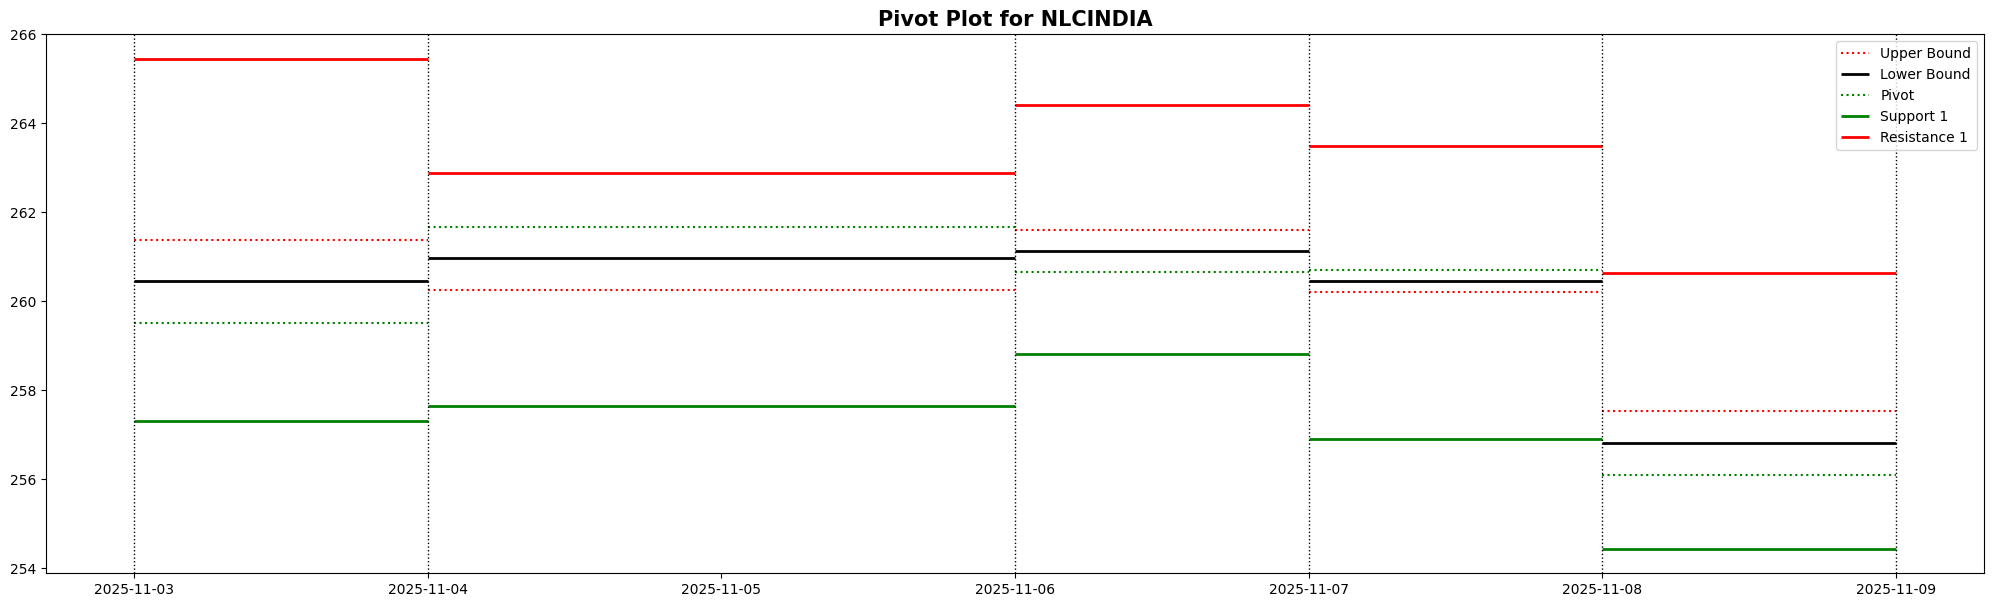

In [11]:
data = In.open_live_stock_data('NLCINDIA')
pivot_data = In.get_Pivot_Points(data, plot = True, num_days_back=5) # access pivot_data to see exact values of support resistances and pivots and pivots boundries

## Narrow Range (Stock Selection)
If recent candle's range is lowest among `X` other days then the future candle might break it's low/high

In [8]:
for name in In.data['nifty_500']:
    if Intra.NR_strategy(name, range_ = 20):
        print(Intra.prob_by_percent_change(symbol = [name], index = None, time_period = 10, change_percent=0.07),In.get_index(name,'all'))

2025-11-11 09:45:16,054 - MainProcess - WARNING - Could not find stock 'OLAELEC' in mapping: "Stock 'OLAELEC' not found in all_stocks mapping."


{'BBTC': {'Long Probability': 0.4, 'Short Probability': 0.9}} ['Nifty 500']
{'APTUS': {'Long Probability': 0.5, 'Short Probability': 1.0}} ['Nifty 500']
{'COLPAL': {'Long Probability': 0.2, 'Short Probability': 0.6}} ['Nifty 200']
{'NESTLEIND': {'Long Probability': 0.3, 'Short Probability': 0.5}} ['Nifty 50']
{'ICICIBANK': {'Long Probability': 0.3, 'Short Probability': 0.4}} ['Nifty 50']
{'AGARWALEYE': {'Long Probability': 0.7, 'Short Probability': 0.9}} ['Nifty 500']


2025-11-11 09:45:16,445 - MainProcess - WARNING - Could not find stock 'TATAMOTORS' in mapping: "Stock 'TATAMOTORS' not found in all_stocks mapping."
2025-11-11 09:45:16,758 - MainProcess - WARNING - Could not find stock 'SKFINDIA' in mapping: "Stock 'SKFINDIA' not found in all_stocks mapping."


{'LLOYDSME': {'Long Probability': 0.4, 'Short Probability': 0.8}} ['Nifty 500']
{'CIPLA': {'Long Probability': 0.4, 'Short Probability': 0.5}} ['Nifty 50']
{'JKCEMENT': {'Long Probability': 0.5, 'Short Probability': 0.7}} ['Nifty 500']


2025-11-11 09:45:17,035 - MainProcess - WARNING - Could not find stock 'RELINFRA' in mapping: "Stock 'RELINFRA' not found in all_stocks mapping."


{'HFCL': {'Long Probability': 0.5, 'Short Probability': 0.8}} ['Nifty 500']
{'ALKYLAMINE': {'Long Probability': 0.6, 'Short Probability': 0.7}} ['Nifty 500']
{'METROPOLIS': {'Long Probability': 0.5, 'Short Probability': 0.9}} ['Nifty 500']
{'RAMCOCEM': {'Long Probability': 0.3, 'Short Probability': 1.0}} ['Nifty 500']
{'APARINDS': {'Long Probability': 0.5, 'Short Probability': 0.8}} ['Nifty 500']
{'RITES': {'Long Probability': 0.3, 'Short Probability': 0.6}} ['Nifty 500']
{'HSCL': {'Long Probability': 0.7, 'Short Probability': 0.7}} ['Nifty 500']


## Whole Number Open (Stock Selection + Strategy)
When Open == Low / High in Whole number as `xxx.00` within 15 minutes

In [7]:
Intra.whole_number_strategy(nifty=500, min_val=101, max_val=5000, print_results = True)

Long :
 Name - Change - ATR - Change% - Remaining Move - Index:

('BEML', np.float64(33.8), np.float64(228.95), '1.68%', np.float64(-0.85), 'Nifty 500') 

('CREDITACC', np.float64(32.0), np.float64(59.78), '2.29%', np.float64(-0.46), 'Nifty 500') 

('SYRMA', np.float64(36.4), np.float64(30.87), '4.44%', np.float64(0.18), 'Nifty 500') 

Short :
 Name - Change - ATR - Change% - Remaining Move - Index:

('OBEROIRLTY', np.float64(13.4), np.float64(38.96), '0.75%', np.float64(-0.66), 'Nifty 200') 

('MOTILALOFS', np.float64(13.2), np.float64(34.3), '1.31%', np.float64(-0.62), 'Nifty 200') 

('ENDURANCE', np.float64(36.0), np.float64(89.5), '1.27%', np.float64(-0.6), 'Nifty 500') 

('SUNTV', np.float64(6.0), np.float64(14.24), '1.08%', np.float64(-0.58), 'Nifty 500') 

('ACC', np.float64(13.9), np.float64(32.63), '0.75%', np.float64(-0.57), 'Nifty 200') 

('CAPLIPOINT', np.float64(24.9), np.float64(57.36), '1.28%', np.float64(-0.57), 'Nifty 500') 

('CLEAN', np.float64(13.0), np.float64(30.1

## `%` Change probability (Stock Selection)
Gives the stock names which have the highest probability of providing you `x%` in intraday atleast on both long or short side based on the previous `N` days record

In [ ]:
# Gives you top 10 stocks from Nifty 500 which have the highest probability of giving atleast 0.99% on your investment based on the Long/Buy position. Data is based on past 60 trading days
# Test it for different time duration, index, % change and Long / Short criteria based on overall market trend
Intra.prob_by_percent_change(symbol = None, index = 200, time_period = 20, change_percent=0.099, sort_by='Long Probability', top_k = 10) 

## ATR 
If stock has crossed it's ATR on either side, it might reverse or if it hasn't, there is still a chance to move

In [ ]:
df = Intra.ATR_strategy(index = 'NIFTY 200', possible_reversal=False) # if possible_reversal is true, it'll just reverse the order of remaining move %
df.head(20)

# [Live Market]()

## Minutes LIVE Data 🤯🤯🤯🤯🤑🤑🤑🤑🥳️🥳️🥳️
Yup! Package now supports `[2,3,4,5,10,15,30,60]` minutes Live Data Too! Finally!!

In order to access the data, there is a unique code associated with every name and is known only to them. You need to write the code for the stock you want to access. This is one time process per stock. You can find that code as follows:

1. Login to `Kite` from your PC and open the chart of `5` minutes for any stock you want to analyse.
2. Click `Ctrl + Shift + I` in Chrome. A new small panel will get opened on the right hand side of screen.
3. Find **NETWORK** in the upper region of that panel. It'll be in the upper region only next to `Elements | Console | Sources | Network`. Click on **NETWORK**
4. Click `CTRL+R` to reload. You'll find something that starts with `5minute?user_id=` under `Name`. [You'll be looking at something like this. Highlighted `holdings` is equal to your `5minute?user_id=`](https://marketsetup.in/posts/zerodha-login/portfolio.png). Click on it and see `Headers` just like in the picture.
5. You'll see a Something like `Request URL: https://kite.zerodha.com/oms/instruments/historical/2513665/5minute?user_id=AB1234&oi=1&from=2022-01-09&to=2022-01-14`
6. The number after `/historical/2513665` is the one you are looking for. So in this case, it is `HAVELLS` code. Save it for future purpose.

### Please help me help you. I am trying to help more and more people. Not everyone can get this code easily and I can not get all the 1600 codes for everyone. If you are looking for a stock and find it's code, just send me a `feature request` or `raise an issue` and paste  the code along with scrip name there so that more and more people can be helped.

In [ ]:
# Kite = KiteZerodha(user_id = 'AB1234',password = "password@123",two_factor_pin = 123456) # You'll be logged out from your PC as much as I know
# df =  Kite.get_historical_minutes_data(name = 'HAVELLS', code = None, interval = 15, starting_from_date = None, no_days_back = 50, get_latest_only = False) # can also directly use code = 2513665
# # Get 15 minutes data of HINDPETRO starting from Today (including current candles) to the previous 50 days. If get_latest_only = True, it would give you 1 days day i.e Today
# df

## Market Sentiment: TICK, TRIN (Arm's Index) & 52W High-Low touching shares

In [ ]:
MS.get_live_sentiment()

## [Volatility Index: VIX](https://www.motilaloswal.com/blog-details/6-things-that-the-Volatility-Index-(VIX)-indicates-to-you../1929)

In [ ]:
NSE.get_VIX()

## MMI: [Market Mood Index](https://www.tickertape.in/market-mood-index)

Please click on the link above to get the values. All credits to [Ticker Tape Website](https://www.tickertape.in/)

In [ ]:
get_mmi(raw = True) # True means a simple Json shows current, last week, last month MMI

## Current Index Performance
Includes Nifty, Thematic and Sectoral indices and show `Top-N` sorted by change %

In [ ]:
NSE.current_indices_status(10) # Live as of market is open. works post market also

In [ ]:
NSE.open_nse_index('NIFTY ENERGY',) # Returns performance of stocks in a given index

In [ ]:
In.stock_current_index_performance('HAVELLS') # All the eligible indices (and their current performance) where this stock belongs to. Some stocks might not belong aywhere

## Stocks trading at their 52W Low / High

In [ ]:
NSE.stocks_at_52W(direction = 'low') # set direction = 'high' for stocks going up

# Futures and Options

## [Analyse Option Chain](https://www.quora.com/How-do-I-read-analyse-the-option-chain-of-a-stock-to-intraday-trade-with-clarity-NSE). Very helpful

In [ ]:
filtered_df = analyse_option_chain('TATACHEM', plot = True, fig_size=(21,6.7)) # Read the Doc String. Manually compare other parameters such as openInterest

# [Back Testing](https://www.investopedia.com/terms/b/backtesting.asp)
## Back Testing Stratagies to get the best Win %, Max Return Investment etc
Pass in the parameters dict for all. Check Docstring of each individual function for how a strategy works in buying or selling.

## CCI
`BT.backtest('cci', stocks=['DIVISLAB'])` , for individual stock data performance to tell how much a stock would have gained or lost

In [ ]:
cci_parameters = {'buying_thresh':-100, 'selling_thresh':100, 'window':20, 'cols':('OPEN','CLOSE','LOW','HIGH', 'DATE')} # check documentation of BT.cci()

# Using the CCI strategy, Return top gaining stocks which have traded atleast 365 recent days and are currently in nifty-500
BT.backtest('cci', min_days = 365, top_n=10, stocks = 'nifty_500', **cci_parameters)

## MA
Moving Average Strategy

In [ ]:
BT.backtest('ma',stocks='nifty_50',top_n=5)

## RSI

In [ ]:
BT.backtest('rsi',stocks='nifty_500', top_n = 5) 

## MACD

In [ ]:
BT.backtest('macd', top_n=5, stocks=['BAJFINANCE','SHREECEM',"COALINDIA"]) # Individual stocks. If no sells have been made, it'll be empty

## Stochastic Oscillator
Faster signal than MACD. Pass in the paramerters to change results and modify to your ease

In [ ]:
BT.backtest('stochastic_osc',stocks='nifty_50', top_n = 15) 

# [Risk Management](https://www.youtube.com/watch?v=v3lfIdpKSiU)

You have a total budget of 40K, and a risk apetite of rs 400 per trade, You can set manual such as `entry = 3980.1` and `stop_loss=3780.5`. If intraday, set `leverage` parameter to `>1` 

In [ ]:
In.get_particulars('NIITLTD',budget = 40000, risk = 400,)  #manually set parameters for entry, exit etc

# Connect to Online Brokers
First step towards Algo trading

## Zerodha / Kite

In [ ]:
Kite = KiteZerodha(user_id = 'AB1234',password = "password@123",two_factor_pin = 123456)
Kite.check_basic_info('holdings') # can check user info, positions, margins etc 